In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [3]:
from src.utils.montage_processing import *

In [4]:
df_metadata = pd.read_csv("../resources/TEP_dataset.csv")
df_metadata = df_metadata[["sessionID", "setID", "ParticipantName", "spot", "angle_yaw", "Task"]]
df_metadata = df_metadata.loc[df_metadata.sessionID >= 29]
df_metadata[-10:]

,sessionID,setID,ParticipantName,spot,angle_yaw,Task
184,34,5,Бердышев Даниил,SMA,90,SST
185,34,6,Бердышев Даниил,SMA,90,SST
186,34,7,Бердышев Даниил,M1-right,45,MI
187,35,1,Васильев Анатолий,SMA,90,MI
188,35,2,Васильев Анатолий,M1,45,MI
189,35,3,Васильев Анатолий,M1-shift,45,MI
190,35,4,Васильев Анатолий,M1-right,45,MI
191,35,5,Васильев Анатолий,M1,-135,MI
192,35,6,Васильев Анатолий,M1,45,MI
193,35,7,Васильев Анатолий,SMA,90,MI


In [5]:
filename_colors = r"../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values
positions = get_topo_positions(CED_FILE)

In [6]:
ROI_contra = ["C3", "C5", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

In [7]:
Fs = 5000
ms_to_s = lambda x: int(Fs * x / 1000)

In [9]:
# === config ===
# data_folder = r"D:\2025 - TEP\data - trans\CLEAN_EPOCHS"
data_folder = r"..\data\pilot\MI_SMA_phases_v2"
records = os.listdir(data_folder)
# records = [record for record in records if record.find("projectionMatrix") == -1 and record.find("png") == -1 and record.find("28") == -1]

In [10]:
record = records[0]
filename = os.path.join(data_folder, record)

def get_data(filename):
    with File(filename, "r") as h5f:
        epochs = h5f["data"]["Epruned"][:]
        tvec = h5f["data"]["tvec"][:]
        conds = h5f["data"]["conds"][:]
    return epochs, tvec, conds

epochs, tvec, conds = get_data(filename)

print(f"Выбранный файл: {filename}")
print(f"Epochs shape: {epochs.shape}")

Выбранный файл: ..\data\pilot\MI_SMA_phases_v2\session_29__set_1.h5
Epochs shape: (3501, 72, 64)


In [13]:
def find_records(records, df, tasks=None, spot=None, angle=None, participant=None):
    df_curr = df.copy()
    if participant is not None:
        df_curr = df_curr.loc[(df_curr.ParticipantName == participant)]
    if tasks is not None:
        df_curr = df_curr.loc[(df_curr.Task.isin(tasks))]
    if spot is not None:
        df_curr = df_curr.loc[(df_curr.spot == spot)]
    if angle is not None:
        df_curr = df_curr.loc[(df_curr.angle_yaw == angle)]
    
    new_records = []
    for row in df_curr.itertuples():
        record = [record for record in records if record.find(f"session_{row.sessionID}__set_{row.setID}") != -1][0]
        new_records.append(record)
    return df_curr, new_records

tasks = ["MI", "real"]
spot = "M1"
angle = "45"
participant="Васильев Анатолий"

df_task, task_records = find_records(records, df_metadata, tasks, spot, angle=angle, participant=participant)
df_task.shape

(5, 6)

In [14]:
df_task

,sessionID,setID,ParticipantName,spot,angle_yaw,Task
155,31,3,Васильев Анатолий,M1,45,real
156,31,4,Васильев Анатолий,M1,45,MI
171,33,1,Васильев Анатолий,M1,45,MI
188,35,2,Васильев Анатолий,M1,45,MI
192,35,6,Васильев Анатолий,M1,45,MI


In [21]:
data_folder

'..\\data\\pilot\\MI_SMA_phases_v2'

In [24]:
filename = r"../data/pilot/MI_SMA_phases_v2/session_31__set_3.h5"

import h5py 
with h5py.File(filename, "r") as hdf:
    print(hdf["data"].keys())
    epochs = hdf["data"]["Epruned"][:]
    time = hdf["data"]["tvec"][:]
    conds = hdf["data"]["conds"][:]

<KeysViewHDF5 ['Epruned', 'tvec', 'conds']>


In [33]:
epochs.shape

(3501, 75, 64)

In [34]:
TEPs = np.mean(epochs, axis=1)  # усреднение по людям
TEPs.shape

(3501, 64)

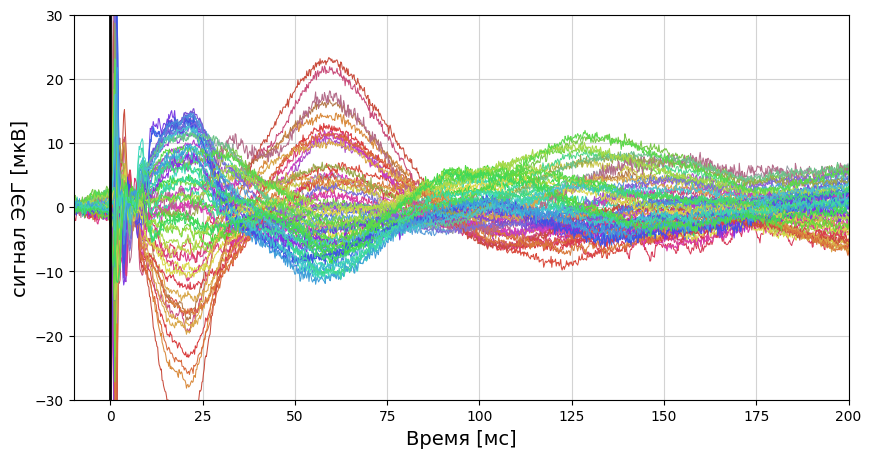

In [39]:
tmin, tmax = -10, 200
amp = 30

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# TEPs_avr_all = np.mean(TEPs, axis=0)
for color, TEP in zip(colors, TEPs.T): # начало движения
    ax.plot(time, TEP, color=color, linewidth=.75)
ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
ax.grid(color="lightgrey")

# ax.set_title('ТВП в М1 в момент выполнения движения', fontsize=18)

ax.axvline(0, color="black", linewidth=2)

In [48]:
def plot_butterfly(tep, tmin, tmax, tlim, amp, ROI_channnels, ax, xlabel, ylabel, title, labels=False):
    mask_interest = ((tvec >= tlim[0]) & (tvec <= tlim[1])).flatten()

    ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_channnels]

    alpha = np.array([0.3] * TEPs.shape[1])
    alpha[ROI_idx] = 1

    width = np.array([.6] * TEPs.shape[1])
    width[ROI_idx] = 1.2

    lines = []
    ch = 0
    for color, TEP in zip(colors, tep.T): # начало движения
        label = ROI_channnels[ROI_idx.index(ch)] if ch in ROI_idx else None
        if ch in ROI_idx:
            # Вся линия очень прозрачная
            ax.plot(tvec, TEP, color=color, alpha=0.7, linewidth=width[ch], zorder=1)
            # Только область интереса нормальная
            ax.plot(tvec[mask_interest], TEP[mask_interest], 
                color=color, alpha=alpha[ch], linewidth=width[ch], zorder=2) #, label=label)
        else:
            ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch], zorder=1)

        # ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch]) #, label=label)
        ch += 1

    roi_tep = np.mean(tep[:, ROI_idx], axis=1)
    ax.plot(tvec, roi_tep, color="#282930", alpha=0.7, linewidth=3)
    # Только область интереса нормальная
    ax.plot(tvec[mask_interest], roi_tep[mask_interest], 
            color="#282930", alpha=1, linewidth=3, zorder=2, label="ROI mean")

    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(color="lightgrey")

    # ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )
    # ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )

    a = 0.4
    ax.axvspan(tmin, tlim[0], alpha=a, color='darkgrey', zorder=0)
    ax.axvspan(tlim[1], tmax, alpha=a, color='darkgrey', zorder=0)

    ax.axvline(0, color="black", linewidth=2)

In [49]:
ROI_N20 = ["C5", "C3",  "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_P60 = ["C3", "C1", "CP3",  "CP1", "P3", "P1"]
ROI_ipsi = ["FCz", "Cz", "CPz", "FC2", "C2", "CP2", "C4", "CP4"]

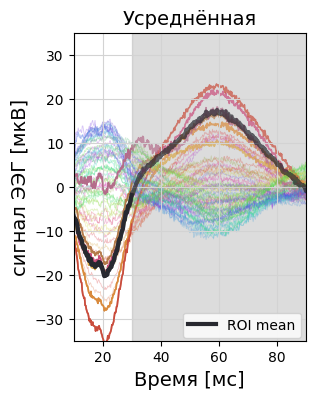

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4), sharex=True, sharey=True)

amp = 35
tmin, tmax = 10, 90

tlim = 10, 30

plot_butterfly(TEPs, tmin, tmax, tlim, amp, ROI_P60, ax, xlabel="Время [мс]", ylabel="сигнал ЭЭГ [мкВ]", title="Усреднённая")
# plot_butterfly(TEPs_avr_all, tmin, tmax, tlim, amp, ROI_ipsi, ax[1], xlabel="", ylabel="", title="Во время движения")
# plot_butterfly(TEPs_avr_all, tmin, tmax, tlim, amp, ROI_ipsi, ax[2], xlabel="", ylabel="", title="Покой")

handles, labels = ax.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax.legend(handles, labels, loc=[.47, 0.01], frameon=True, fancybox=True)

fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg_{tlim}.png")
plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

In [61]:
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_N20]
TEPs_ROI = np.mean(TEPs[:, ROI_idx], axis=1)

tlim = (10, 30)
mask_interest = ((tvec >= tlim[0]) & (tvec <= tlim[1])).flatten()

TEPs_ROI_tlim = TEPs_ROI[mask_interest]
TEP_amp, TEP_idx = np.nanmin(TEPs_ROI_tlim), np.argmin(TEPs_ROI_tlim)
TEP_amp, TEP_idx

(np.float32(-22.542397), np.int64(53))

In [62]:
conds

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1],
       [1, 0, 0],
       [1, 0, 0],
       [0,